# 10 – Cross-attention Fusion

Fusion model combining the signal LSTM and ClinicalBERT text embeddings via masked
cross-attention. Includes attention visualisation and a five-seed sensitivity analysis.

**Run after notebooks 05, 06 and 09b** — uses hourly_vitals.csv,
modelling_cohort_sepsis_mortality.csv, text_hourly_cls_mbert.npz.

**Produces:** preds_crossattn.npz (used by notebook 13); fig_attention_heatmap.png (Fig 4.10).

MIMIC-III data not included (PhysioNet DUA); see README.

In [ ]:
# --- Setup ---
import os

try:
    from config import DATA_DIR
except ImportError:
    DATA_DIR = os.environ.get("ERP_DATA_DIR", "./data")

def data_path(name):
    return os.path.join(DATA_DIR, name)

import numpy as np, pandas as pd, torch
import torch.nn as nn, torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

torch.manual_seed(42); np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

## 1. Load aligned signals, text embeddings, labels

In [ ]:
# text embeddings (24x768) + mask, saved by notebook 09
tz = np.load(data_path("text_hourly_cls_mbert.npz"), allow_pickle=True)
X_text_all = tz["X_text"]        # (N,24,768)
has_note_all = tz["has_note"]    # (N,24)
text_ids = tz["stay_ids"]        # ICUSTAY_ID order for the text arrays
print("text:", X_text_all.shape, "| mask:", has_note_all.shape)

# signals
vitals = pd.read_csv(data_path("hourly_vitals.csv"))
cohort = pd.read_csv(data_path("modelling_cohort_sepsis_mortality.csv"))
labels = cohort[["ICUSTAY_ID","mortality_after_24h"]].drop_duplicates()

text: (10068, 24, 768) | mask: (10068, 24)


In [ ]:
VITAL_COLS = [
    "heart_rate",
    "sbp",
    "dbp",
    "map",
    "resp_rate",
    "temperature",
    "spo2",
    "fio2",
    "glucose",
    "ph",
    "gcs_eye",
    "gcs_motor",
    "gcs_total",
    "gcs_verbal",
    "weight",
    "height"
]

MASK_COLS = [c + "_observed" for c in VITAL_COLS]
FEAT_COLS = VITAL_COLS + MASK_COLS

# use the SAME stay order as the text file so signals/text/labels line up
stay_ids = text_ids
y = labels.set_index("ICUSTAY_ID")["mortality_after_24h"]

# build signal grid (N,24,14) in the same order, standardised on training set later
vitals = vitals[vitals["ICUSTAY_ID"].isin(set(stay_ids))].copy()
# reindex to full stay x hour grid
full_idx = pd.MultiIndex.from_product([stay_ids, range(24)], names=["ICUSTAY_ID","ICU_HOUR"])
vit = (vitals.set_index(["ICUSTAY_ID","ICU_HOUR"]).reindex(full_idx)[FEAT_COLS])
# scale vitals on training rows only (done after split below) -- keep raw for now
X_sig_raw = vit[FEAT_COLS].values.reshape(len(stay_ids),24,len(FEAT_COLS)).astype("float32")
print("signal:", X_sig_raw.shape)

signal: (10068, 24, 32)


## 2. Patient-level split (same seed as the baselines)

In [ ]:
# ------------------------------------------------------------------
# Patient-level train / validation / test split
# ------------------------------------------------------------------

train_ids, temp_ids = train_test_split(
    stay_ids,
    test_size=0.30,
    random_state=42,
    stratify=y.loc[stay_ids].values
)

val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.50,
    random_state=42,
    stratify=y.loc[temp_ids].values
)

# Map ICUSTAY_ID -> row position in X_sig_raw / X_text_all
pos = {
    s: i
    for i, s in enumerate(stay_ids)
}

def idx(ids):
    return [pos[s] for s in ids]


# ------------------------------------------------------------------
# Standardise physiological variables using TRAINING SET ONLY
# Observation-mask columns remain binary 0/1
# ------------------------------------------------------------------

tr_idx = idx(train_ids)

n_vitals = len(VITAL_COLS)

vit_part = X_sig_raw[:, :, :n_vitals]

tr_vals = vit_part[tr_idx].reshape(
    -1,
    n_vitals
)

mu = np.nanmean(tr_vals, axis=0)
sd = np.nanstd(tr_vals, axis=0)
sd[sd == 0] = 1

X_sig = X_sig_raw.copy()

X_sig[:, :, :n_vitals] = (
    X_sig[:, :, :n_vitals] - mu
) / sd

# residual NaNs -> training mean after standardisation
X_sig = np.nan_to_num(
    X_sig,
    nan=0.0
)

print(
    "train/val/test:",
    len(train_ids),
    len(val_ids),
    len(test_ids)
)

print(
    "standardised signals:",
    X_sig.shape
)

train/val/test: 7047 1510 1511
standardised signals: (10068, 24, 32)


In [ ]:
def make(ids):
    i = idx(ids)
    return (torch.tensor(X_sig[i]), torch.tensor(X_text_all[i]),
            torch.tensor(has_note_all[i]), torch.tensor(y.loc[ids].values.astype("float32")))

Xs_tr,Xt_tr,m_tr,y_tr = make(train_ids)
Xs_va,Xt_va,m_va,y_va = make(val_ids)
Xs_te,Xt_te,m_te,y_te = make(test_ids)
print("train:", Xs_tr.shape, Xt_tr.shape)

tr_loader = DataLoader(TensorDataset(Xs_tr,Xt_tr,m_tr,y_tr), batch_size=128, shuffle=True)

train: torch.Size([7047, 24, 32]) torch.Size([7047, 24, 768])


## 3. Cross-attention fusion model

In [ ]:
class CrossAttnFusion(nn.Module):
    def __init__(
        self,
        sig_dim=len(FEAT_COLS),
        text_dim=768,
        d=128,
        heads=4,
        dropout=0.3
    ):
        super().__init__()

        self.sig_lstm = nn.LSTM(
            sig_dim,
            d,
            batch_first=True
        )

        self.text_proj = nn.Linear(
            text_dim,
            d
        )

        self.cross = nn.MultiheadAttention(
            d,
            heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm = nn.LayerNorm(d)
        self.drop = nn.Dropout(dropout)

        self.fc = nn.Sequential(
            nn.Linear(d, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, sig, text, note_mask):
        s, _ = self.sig_lstm(sig)           # (B, 24, d)
        t = self.text_proj(text)             # (B, 24, d)

        key_pad = note_mask == 0             # True = ignore

        all_zero = key_pad.all(dim=1)
        key_pad = key_pad.clone()
        key_pad[all_zero] = False

        attn_out, attn_w = self.cross(
            s,
            t,
            t,
            key_padding_mask=key_pad
        )

        fused = self.norm(
            s + self.drop(attn_out)
        )

        pooled = fused.mean(dim=1)

        logits = self.fc(pooled).squeeze(1)

        return logits, attn_w

import random
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

model = CrossAttnFusion(
    d=128,
    heads=4,
    dropout=0.3
).to(device)

print(model)

CrossAttnFusion(
  (sig_lstm): LSTM(32, 128, batch_first=True)
  (text_proj): Linear(in_features=768, out_features=128, bias=True)
  (cross): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (drop): Dropout(p=0.3, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 4. Train

In [ ]:
pr = float(y_tr.mean()); pw = torch.tensor([(1-pr)/pr], device=device)
crit = nn.BCEWithLogitsLoss(pos_weight=pw)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

@torch.no_grad()
def ev(Xs,Xt,m,yv):
    model.eval()
    logit,_ = model(Xs.to(device),Xt.to(device),m.to(device))
    p = torch.sigmoid(logit).cpu().numpy(); yt = yv.numpy()
    return roc_auc_score(yt,p), average_precision_score(yt,p), f1_score(yt,(p>=0.5).astype(int))

best,bs = 0,None
for ep in range(1,61):
    model.train()
    for xs,xt,mm,yb in tr_loader:
        xs,xt,mm,yb = xs.to(device),xt.to(device),mm.to(device),yb.to(device)
        opt.zero_grad()
        logit,_ = model(xs,xt,mm)
        crit(logit,yb).backward(); opt.step()
    va,vap,vf1 = ev(Xs_va,Xt_va,m_va,y_va)
    if ep%5==0 or ep==1: print(f"epoch {ep:2d} | val AUROC {va:.3f} AUPRC {vap:.3f} F1 {vf1:.3f}")
    if va>best: best,bs = va,{k:v.cpu().clone() for k,v in model.state_dict().items()}
model.load_state_dict(bs)

epoch  1 | val AUROC 0.787 AUPRC 0.489 F1 0.501
epoch  5 | val AUROC 0.798 AUPRC 0.517 F1 0.498
epoch 10 | val AUROC 0.792 AUPRC 0.501 F1 0.496
epoch 15 | val AUROC 0.785 AUPRC 0.491 F1 0.510
epoch 20 | val AUROC 0.772 AUPRC 0.450 F1 0.490
epoch 25 | val AUROC 0.758 AUPRC 0.460 F1 0.475
epoch 30 | val AUROC 0.757 AUPRC 0.461 F1 0.474
epoch 35 | val AUROC 0.749 AUPRC 0.418 F1 0.480
epoch 40 | val AUROC 0.737 AUPRC 0.421 F1 0.458
epoch 45 | val AUROC 0.731 AUPRC 0.415 F1 0.406
epoch 50 | val AUROC 0.744 AUPRC 0.435 F1 0.416
epoch 55 | val AUROC 0.739 AUPRC 0.427 F1 0.401
epoch 60 | val AUROC 0.731 AUPRC 0.420 F1 0.414


<All keys matched successfully>

## 5. Test result vs baselines

In [ ]:
au,ap,f1 = ev(Xs_te,Xt_te,m_te,y_te)
print("=== Cross-attention fusion (test) ===")
print(f"AUROC: {au:.3f}\nAUPRC: {ap:.3f}\nF1   : {f1:.3f}")
print("\n--- comparison ---")
print(f"signal-only : AUROC 0.675")
print(f"text-only   : AUROC 0.669")
print(f"fusion      : AUROC {au:.3f}")

=== Cross-attention fusion (test) ===
AUROC: 0.794
AUPRC: 0.512
F1   : 0.515

--- comparison ---
signal-only : AUROC 0.675
text-only   : AUROC 0.669
fusion      : AUROC 0.794


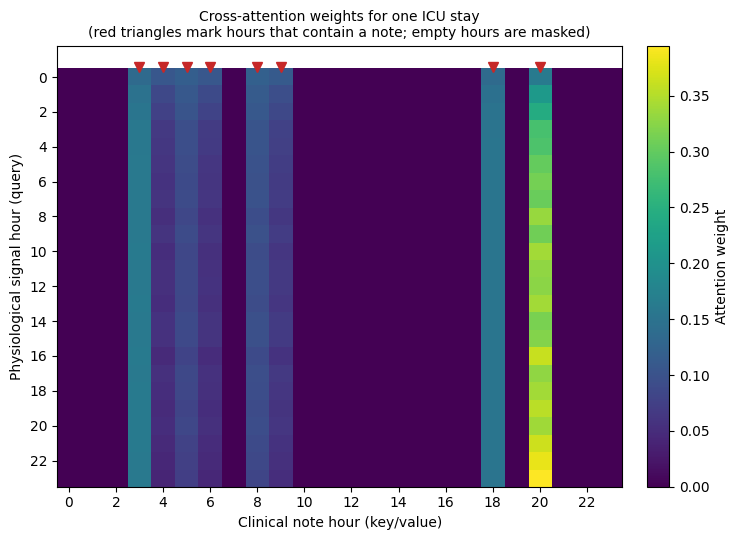

note hours: [3, 4, 5, 6, 8, 9, 18, 20]


In [ ]:
# ===== Cross-attention heatmap (Figure in report) =====
import numpy as np, torch, matplotlib.pyplot as plt

PROBE = 227225
i = pos[PROBE]

# run once to obtain the full (24 query x 24 key) attention matrix
model.eval()
xs = torch.tensor(X_sig[i:i+1]).to(device)
xt = torch.tensor(X_text_all[i:i+1]).to(device)
mm = torch.tensor(has_note_all[i:i+1]).to(device)
with torch.no_grad():
    _, attn_w = model(xs, xt, mm)

A = attn_w[0].detach().cpu().numpy()          # (24 query, 24 key)
note_mask = np.asarray(has_note_all[i]).astype(int)
note_hours = np.where(note_mask == 1)[0]

fig, ax = plt.subplots(figsize=(7.5, 5.5))

# heatmap: rows = signal hour (query), cols = note hour (key)
im = ax.imshow(A, aspect="auto", origin="upper", cmap="viridis",
               interpolation="nearest")

# mark note-bearing columns
for h in note_hours:
    ax.plot(h, -0.6, marker="v", color="#c62828", markersize=7, clip_on=False)

ax.set_xlabel("Clinical note hour (key/value)")
ax.set_ylabel("Physiological signal hour (query)")
ax.set_xticks(range(0, 24, 2))
ax.set_yticks(range(0, 24, 2))
ax.set_title("Cross-attention weights for one ICU stay\n"
             "(red triangles mark hours that contain a note; empty hours are masked)",
             fontsize=10)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Attention weight")

plt.tight_layout()
plt.savefig("fig4_4_attention_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("note hours:", note_hours.tolist())

In [ ]:
@torch.no_grad()
def predict_probs(Xs, Xt, m):
    model.eval()
    logit, _ = model(Xs.to(device), Xt.to(device), m.to(device))
    return torch.sigmoid(logit).cpu().numpy()

p_te = predict_probs(Xs_te, Xt_te, m_te)
np.savez(data_path("preds_crossattn.npz"),
         stay_ids=np.array(test_ids), y_true=y_te.numpy(), y_prob=p_te)
print("saved preds_crossattn.npz", p_te.shape)

saved preds_crossattn.npz (1511,)


In [ ]:
# ===== Multi-seed sensitivity analysis (Appendix D) =====
import numpy as np, torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

SEEDS = [42, 1, 2, 3, 4]
_res = []

def _ev_test(m):
    m.eval()
    with torch.no_grad():
        logit, _ = m(Xs_te.to(device), Xt_te.to(device), m_te.to(device))
        p = torch.sigmoid(logit).cpu().numpy()
    yt = y_te.numpy()
    return (roc_auc_score(yt, p), average_precision_score(yt, p),
            f1_score(yt, (p >= 0.5).astype(int)))

def _ev_val(m):
    m.eval()
    with torch.no_grad():
        logit, _ = m(Xs_va.to(device), Xt_va.to(device), m_va.to(device))
        p = torch.sigmoid(logit).cpu().numpy()
    return roc_auc_score(y_va.numpy(), p)

for seed in SEEDS:
    torch.manual_seed(seed); np.random.seed(seed)
    m = CrossAttnFusion(d=128, heads=4, dropout=0.3).to(device)
    pr = float(y_tr.mean()); pw = torch.tensor([(1-pr)/pr], device=device)
    crit = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    best, bs = 0, None
    for ep in range(1, 61):
        m.train()
        for xs, xt, mm, yb in tr_loader:
            xs, xt, mm, yb = xs.to(device), xt.to(device), mm.to(device), yb.to(device)
            opt.zero_grad(); logit, _ = m(xs, xt, mm); crit(logit, yb).backward(); opt.step()
        va = _ev_val(m)
        if va > best: best, bs = va, {k:v.cpu().clone() for k,v in m.state_dict().items()}
    m.load_state_dict(bs)
    au, ap, f1 = _ev_test(m)
    _res.append((au, ap, f1)); print(f"seed {seed}: AUROC {au:.3f} AUPRC {ap:.3f} F1 {f1:.3f}")

_res = np.array(_res)
print(f"\nCross-attn  AUROC {_res[:,0].mean():.3f} ± {_res[:,0].std():.3f}"
      f" | AUPRC {_res[:,1].mean():.3f} ± {_res[:,1].std():.3f}"
      f" | F1 {_res[:,2].mean():.3f} ± {_res[:,2].std():.3f}")

seed 42: AUROC 0.794 AUPRC 0.512 F1 0.515
seed 1: AUROC 0.793 AUPRC 0.517 F1 0.528
seed 2: AUROC 0.792 AUPRC 0.499 F1 0.525
seed 3: AUROC 0.788 AUPRC 0.508 F1 0.520
seed 4: AUROC 0.791 AUPRC 0.509 F1 0.523

Cross-attn  AUROC 0.791 ± 0.002 | AUPRC 0.509 ± 0.006 | F1 0.522 ± 0.004
